- BLOK A — cechy naprawdę istotne (liniowe)         [X1, X2, X3]
- BLOK B — cechy istotne nieliniowo                  [X4, X5]
- BLOK C — cechy istotne przez interakcję           [X6, X7]
- BLOK D — cechy skorelowane z istotnymi            [X8–X12]
- BLOK E — cechy o niskiej wariancji (prawie stałe) [X13, X14]
- BLOK F — czysty szum                    [X15–X25]
- BLOK G — cechy dyskretne / kategoryczne           [X26–X30]

- BLOK A
    - X1 ~ N(0,1)
    - X2 ~ N(0,1)
    - X3 ~ Exp(λ=1)
- BLOK B
    - X4 ~ N(0,1)
    - X5 ~ U(-3, 3)
- BLOK C
    - X6 ~ N(0,1)
    - X7 ~ N(0,1)
- BLOK D
    - X8 = $0.95 \cdot X_1 + \sqrt{1 - 0.95^2} \cdot \mathcal{N}(0, 1)$ - silna korelacja z X1
    - X9 = $0.80 \cdot X_1 + \sqrt{1 - 0.80^2} \cdot \mathcal{N}(0, 1)$ - trochę słabsza korelacja z X1
    - X10 = $0.90 \cdot X_4 + \sqrt{1 - 0.90^2} \cdot \mathcal{N}(0, 1)$ - korelacja ze zmienna istotną nieliniowo
    - X11 = $0.80 \cdot X_6 + \sqrt{1 - 0.80^2} \cdot \mathcal{N}(0, 1)$ - korelacja z połową interakcji
    - X12 = $0.50 \cdot X_3 + 0.50 \cdot X_1 + \sqrt{1 - 0.5^2 - 0.5^2} \cdot \mathcal{N}(0, 1)$ - kobminacja liniowa dwóch zmiennych 
- BLOK E
    - X13 ~ N(0,0.01) - istotna o niskiej wariancji
    - X14 ~ N(0.0.005) - nieistotna
- BLOK F
    - $X_{15} \dots X_{20} \sim \mathcal{N}(0, 1)$ - szum gausowski
    - X21-X23 ~ U(-2,2) - szum jednostajny
    - X24-X25 ~ N(0,1) - skorelowane ze sobą 
- BLOK G
    - X26 ~ Bern(0.5) - isotna
    - X27 ~ Bin(4,0.5) - istotna
    - X28 ~ Bern(0.8) - nieistotna
    - X29-X30 losowe wartosci {0,1,2,3}

$$Y^* = \beta_1 X_1 + \beta_2 X_2 + \beta_3 X_3 + \beta_4 (X_4^2) + \beta_5 \sin(X_5) + \beta_6 (X_6 \cdot X_7) + \beta_{13} X_{13} + \beta_{26} X_{26} + \beta_{27} X_{27}$$

Przykładowe wartości współczynników:
- Liniowe
    - $\beta_1 = 1.5$
    - $\beta_2 = 1.2$
    - $\beta_3 = 1.1$
- Nieliniowe
    - $\beta_4 = 1.3$
    - $\beta_5 = 1.5$
- Interakacja
    - $\beta_6 = 2.5$
- Niska wariancja
    - $\beta_{13} = 15$
- Kategoryczne
    - $\beta_{26} = 1.7$
    - $\beta_{27} = 1.2$

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import random

rng = np.random.default_rng(seed=111)
random.seed(111)

X1 = rng.normal(0,1,size=1000)
X2 = rng.normal(0,1,size=1000)
X3 = rng.exponential(1,size=1000)

X4 = rng.normal(0,1,size=1000)
X5 = rng.integers(-3,3,size=1000)

X6 = rng.normal(0,1,size=1000)
X7 = rng.normal(0,1,size=1000)

X8 = 0.95*X1+(1-0.95**2)**0.5 * rng.normal(0,1,size=1000)
X9 = 0.8*X1+(1-0.8**2)**0.5 * rng.normal(0,1,size=1000)
X10 = 0.9*X4+(1-0.9**2)**0.5 * rng.normal(0,1,size=1000)
X11 = 0.8*X6+(1-0.8**2)**0.5 * rng.normal(0,1,size=1000)
X12 = 0.5*X1+0.5*X3+(1-0.5**2-0.5**2)**0.5 * rng.normal(0,1,size=1000)

X13 = rng.normal(0,0.01,size=1000)
X14 = rng.normal(0,0.005,size=1000)

X15 = rng.normal(0,1,size=1000)
X16 = rng.normal(0,1,size=1000)
X17 = rng.normal(0,1,size=1000)
X18 = rng.normal(0,1,size=1000)
X19 = rng.normal(0,1,size=1000)
X20 = rng.normal(0,1,size=1000)
X21 = rng.integers(-2,2,size=1000)
X22 = rng.integers(-2,2,size=1000)
X23 = rng.integers(-2,2,size=1000)
X24 = rng.normal(0,1,size=1000)
X25 = 0.95*X24+(1-0.95**2)**0.5 * rng.normal(0,1,size=1000)

X26 = stats.bernoulli.rvs(p=0.5, size=1000)
X27 = rng.binomial(4,0.5,size=1000)
X28 = stats.bernoulli.rvs(p=0.8, size=1000)
X29 = random.choices([0, 1, 2, 3], k=1000)
X30 = random.choices([0, 1, 2, 3], k=1000)

c:\Users\wolfd\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\wolfd\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
slownik_kolumn = {
    'X1': X1,   'X2': X2,   'X3': X3,   'X4': X4,   'X5': X5,
    'X6': X6,   'X7': X7,   'X8': X8,   'X9': X9,   'X10': X10,
    'X11': X11, 'X12': X12, 'X13': X13, 'X14': X14, 'X15': X15,
    'X16': X16, 'X17': X17, 'X18': X18, 'X19': X19, 'X20': X20,
    'X21': X21, 'X22': X22, 'X23': X23, 'X24': X24, 'X25': X25,
    'X26': X26, 'X27': X27, 'X28': X28, 'X29': X29, 'X30': X30
}

df = pd.DataFrame(slownik_kolumn)

In [6]:
import math

Beta=[1.5,1.2,1.1,1.3,1.5,2.5,15,1.7,1.2]
istotne = {
    'X1': X1,   'X2': X2,   'X3': X3,   'X4': X4,   'X5': X5,
    'X6': X6,   'X7': X7,   'X13': X13, 
    'X26': X26, 'X27': X27
}

df_istotne = pd.DataFrame(istotne)
Y = Beta[0]*X1+Beta[1]*X2+Beta[2]*X3+Beta[3]*X4**2+Beta[4]*np.sin(X5)+Beta[5]*X6*X7+Beta[6]*X13+Beta[7]*X26+Beta[8]*X27

(array([  1.,   1.,   0.,   3.,   6.,  12.,  21.,  50.,  85., 118., 139.,
        150., 138., 104.,  68.,  47.,  18.,  12.,  13.,   2.,   4.,   5.,
          1.,   0.,   2.]),
 array([-10.75183979,  -9.33407692,  -7.91631404,  -6.49855117,
         -5.0807883 ,  -3.66302542,  -2.24526255,  -0.82749968,
          0.5902632 ,   2.00802607,   3.42578895,   4.84355182,
          6.26131469,   7.67907757,   9.09684044,  10.51460332,
         11.93236619,  13.35012906,  14.76789194,  16.18565481,
         17.60341768,  19.02118056,  20.43894343,  21.85670631,
         23.27446918,  24.69223205]),
 <BarContainer object of 25 artists>)

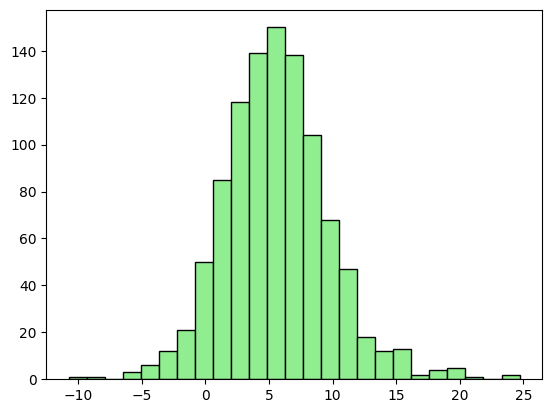

In [7]:
import matplotlib.pyplot as plt

plt.hist(Y, bins=25, color='lightgreen', edgecolor='black')

In [8]:
from scipy.special import expit

beta_0 = -np.median(Y)
Z = Y + beta_0

(array([  1.,   1.,   0.,   3.,   6.,  12.,  21.,  50.,  85., 118., 139.,
        150., 138., 104.,  68.,  47.,  18.,  12.,  13.,   2.,   4.,   5.,
          1.,   0.,   2.]),
 array([-16.26695402, -14.84919115, -13.43142827, -12.0136654 ,
        -10.59590252,  -9.17813965,  -7.76037678,  -6.3426139 ,
         -4.92485103,  -3.50708816,  -2.08932528,  -0.67156241,
          0.74620047,   2.16396334,   3.58172621,   4.99948909,
          6.41725196,   7.83501484,   9.25277771,  10.67054058,
         12.08830346,  13.50606633,  14.92382921,  16.34159208,
         17.75935495,  19.17711783]),
 <BarContainer object of 25 artists>)

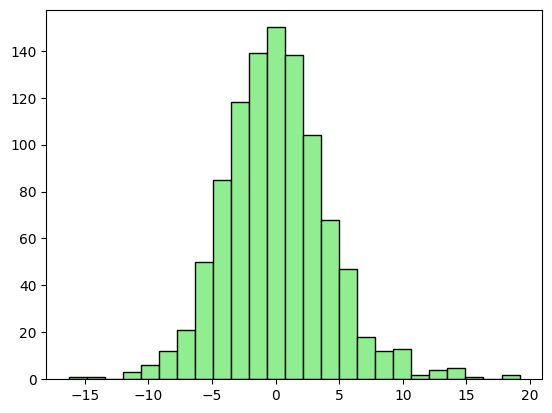

In [9]:
plt.hist(Z, bins=25, color='lightgreen', edgecolor='black')

In [10]:
pstwo = expit(Z)
Y_final = rng.binomial(n=1, p=pstwo)

In [11]:
sum(Y_final)

500

In [12]:
df['Y']=Y_final

In [13]:
df

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X22,X23,X24,X25,X26,X27,X28,X29,X30,Y
0,-0.307438,-0.321008,1.730590,0.833916,-3,0.780486,1.568454,-0.334988,-0.961240,-0.001718,...,-2,1,1.965948,1.653540,0,3,1,3,1,1
1,-0.838657,0.378442,0.920856,1.469715,0,-0.330047,1.083323,-0.500412,-0.285231,0.854438,...,1,1,0.796119,0.521067,0,2,1,0,2,0
2,0.125638,-0.356535,0.902586,0.556410,2,-0.338767,-0.686062,-0.102820,-0.639805,0.562263,...,-2,-1,1.422506,0.731031,0,2,1,3,1,0
3,-0.660677,0.811173,0.392495,0.934048,-1,-1.128626,-0.124899,-0.449230,-0.137603,0.561763,...,1,1,-0.389034,-0.826052,1,2,1,1,1,1
4,0.158315,-0.043223,1.935064,-1.034712,-2,1.277763,-0.925314,0.290902,-1.556194,-0.930982,...,1,-1,1.704167,1.843077,0,3,0,1,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,-1.705845,-0.192785,0.050497,1.182819,-3,-0.769177,1.303321,-1.744339,-0.644756,0.743776,...,1,-1,-1.354313,-1.595279,1,1,0,0,0,0
996,1.286893,-0.297818,0.437682,1.547938,2,-1.092817,0.927605,1.275676,-0.554750,1.578934,...,1,1,0.189722,0.353100,0,4,1,3,1,1
997,-1.117386,-0.358493,1.638156,0.973410,0,-2.239257,-0.008290,-1.106888,-0.013545,0.951992,...,-2,-2,1.434950,1.128374,1,1,1,3,1,0
998,0.086321,-0.234614,1.012391,-0.908960,-2,1.356460,2.426662,-0.186855,0.096933,-0.605418,...,0,0,-0.543628,-0.444018,1,3,1,0,2,1


In [14]:
df.to_excel('dane_syntetyczne.xlsx', index=False)

- Metody oparte na filtrach
    - Variance Threshold: sklearn.feature_selection.VarianceThreshold
    - Korelacja Pearsona: pandas.DataFrame.corr(method='pearson')
    - Chi-kwadrat: sklearn.feature_selection.chi2
    - Informacja Wzajemna: sklearn.feature_selection.mutual_info_classif
    - Anova: sklearn.feature_selection.f_classif
- Metody wbudowane
    - Lasso: LogisticRegression(penalty='l1', solver='liblinear')
    - Las losowy: RandomForestClassifier
- Metody obudowane
    - Forward Selection: sklearn.feature_selection.SequentialFeatureSelector(estimator, direction='forward')
    - Backward Selection: sklearn.feature_selection.SequentialFeatureSelector(estimator, direction='backward')
    - RFE: sklearn.feature_selection.RFE(estimator)
    - Algorytm Genetyczny: sklearn_genetic.GeneticSelectionCV

In [15]:
df_train = df.drop(columns=['Y'])

# Metody oparte na filtrach

In [16]:
from sklearn.feature_selection import  VarianceThreshold

val = VarianceThreshold()
val.fit(df_train)
val.get_support()

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])

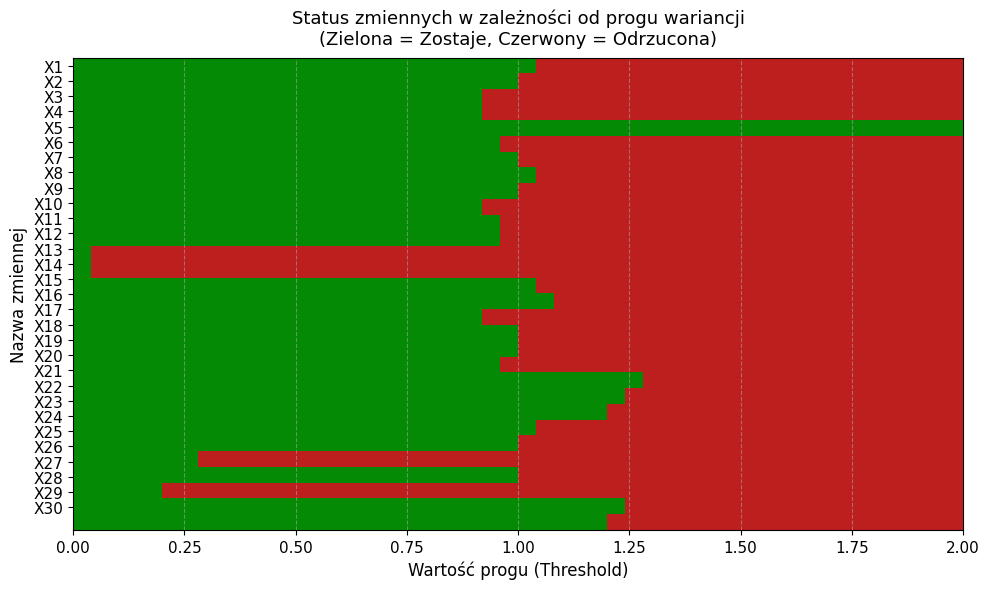

In [17]:
from matplotlib.colors import ListedColormap

cechy_wariancje = df_train.var().sort_values()
progi = np.linspace(0.0, 2.0, 50)

wyniki = []
for p in progi:
    selector = VarianceThreshold(threshold=p)
    selector.fit(df_train)
    wyniki.append(selector.get_support())


df_wyniki = pd.DataFrame(wyniki, index=progi, columns=df_train.columns).T

plt.figure(figsize=(10, 6))

custom_cmap = ListedColormap(['#bd1e1e', '#058a05'])
plt.imshow(df_wyniki.astype(int), cmap=custom_cmap, aspect='auto', 
           extent=[progi.min(), progi.max(), len(df.columns)-0.5, -0.5])


plt.yticks(range(len(df_train.columns)), df_wyniki.index, fontsize=11)
plt.xticks(fontsize=11)


plt.xlabel('Wartość progu (Threshold)', fontsize=12)
plt.ylabel('Nazwa zmiennej', fontsize=12)
plt.title('Status zmiennych w zależności od progu wariancji\n(Zielona = Zostaje, Czerwony = Odrzucona)', fontsize=13, pad=10)

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [18]:
korelacje = df.corr(method='pearson')['Y'].drop('Y')
korelacje_sorted = korelacje.sort_values(ascending=False)
korelacje_sorted = abs(korelacje_sorted)
korelacje_sorted

X8     2.739631e-01
X1     2.672910e-01
X27    2.501495e-01
X2     2.426246e-01
X9     2.141012e-01
X26    1.880963e-01
X12    1.832469e-01
X5     1.499434e-01
X3     1.434760e-01
X23    6.963406e-02
X15    6.411980e-02
X4     3.386614e-02
X13    2.587352e-02
X7     1.766681e-02
X18    1.711087e-02
X17    1.361817e-02
X19    1.250363e-02
X29    9.809428e-03
X10    9.782262e-03
X16    9.573839e-03
X21    8.790089e-03
X24    6.475221e-03
X28    5.328854e-17
X25    2.941785e-03
X14    6.235799e-03
X22    7.114116e-03
X20    2.114157e-02
X30    4.115542e-02
X11    6.961084e-02
X6     8.345158e-02
Name: Y, dtype: float64

In [19]:
top_10 = korelacje_sorted.head(10)
top_10

X8     0.273963
X1     0.267291
X27    0.250149
X2     0.242625
X9     0.214101
X26    0.188096
X12    0.183247
X5     0.149943
X3     0.143476
X23    0.069634
Name: Y, dtype: float64

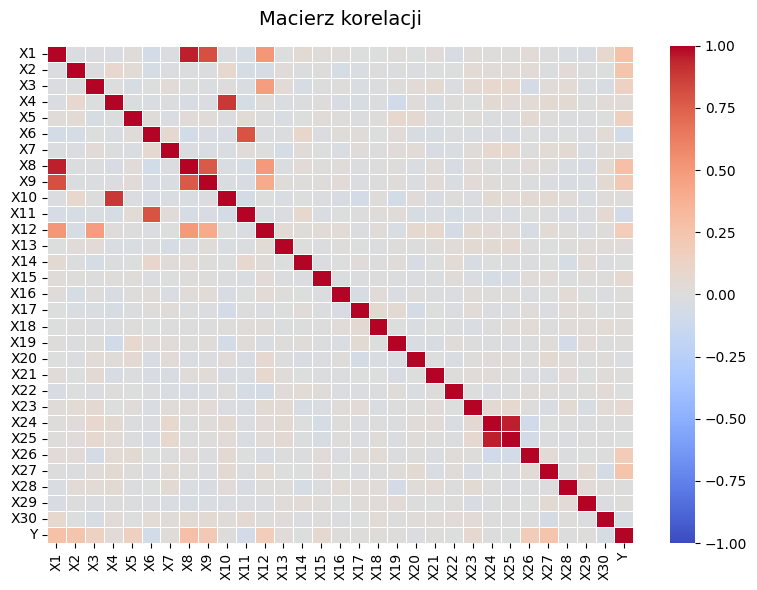

In [20]:
import seaborn as sns

macierz_korelacji = df.corr(method='pearson')

plt.figure(figsize=(8, 6))

sns.heatmap(
    macierz_korelacji, 
    cmap='coolwarm',  
    fmt=".2f",        
    vmin=-1, vmax=1,  
    linewidths=0.5,   
    cbar=True         
)

plt.title('Macierz korelacji', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

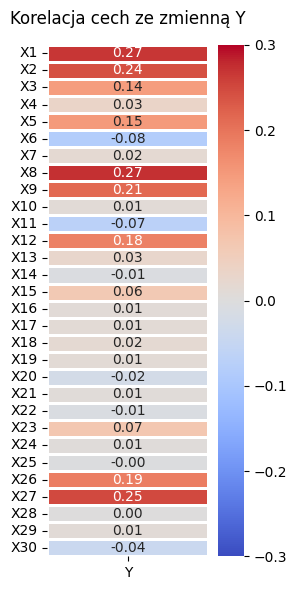

In [21]:
korelacja_Y = df.corr(method='pearson')[['Y']].drop('Y')

plt.figure(figsize=(3, 6))

sns.heatmap(
    korelacja_Y, 
    annot=True,       
    cmap='coolwarm',  
    fmt=".2f",        
    vmin=-0.3, vmax=0.3,  
    linewidths=1,     
    cbar=True        
)

plt.title('Korelacja cech ze zmienną Y', fontsize=12, pad=15)
plt.tight_layout()
plt.show()

In [22]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2

# Zakładamy, że X ma wartości ujemne
scaler = MinMaxScaler()
X_nieujemne = pd.DataFrame(scaler.fit_transform(df_train))
X_nieujemne.columns = range(1, len(X_nieujemne.columns) + 1)
X_nieujemne

,1,2,3,4,5,6,7,8,9,10,...,21,22,23,24,25,26,27,28,29,30
0,0.422438,0.405876,0.290100,0.656817,0.0,0.559566,0.802072,0.427367,0.364991,0.517300,...,1.000000,0.000000,1.000000,0.810868,0.797752,0.0,0.75,1.0,1.000000,0.333333
1,0.348024,0.520708,0.154267,0.763132,0.6,0.386298,0.728554,0.405244,0.464722,0.642932,...,1.000000,1.000000,1.000000,0.624313,0.608387,0.0,0.50,1.0,0.000000,0.666667
2,0.483103,0.400043,0.151202,0.610414,1.0,0.384938,0.460415,0.458416,0.412412,0.600058,...,1.000000,0.000000,0.333333,0.724205,0.643496,0.0,0.50,1.0,1.000000,0.333333
3,0.372956,0.591751,0.065633,0.673560,0.4,0.261702,0.545456,0.412089,0.486502,0.599985,...,1.000000,1.000000,1.000000,0.435315,0.383131,1.0,0.50,1.0,0.333333,0.333333
4,0.487680,0.451481,0.324401,0.344355,0.2,0.637152,0.424158,0.511069,0.277219,0.380939,...,0.333333,1.000000,0.333333,0.769122,0.829445,0.0,0.75,0.0,0.333333,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.226548,0.426927,0.008263,0.715159,0.0,0.317784,0.761893,0.238890,0.411682,0.626693,...,1.000000,1.000000,0.333333,0.281380,0.254506,1.0,0.25,0.0,0.000000,0.000000
996,0.645772,0.409683,0.073214,0.776212,1.0,0.267289,0.704956,0.642766,0.424960,0.749244,...,1.000000,1.000000,1.000000,0.527610,0.580301,0.0,1.00,1.0,1.000000,0.333333
997,0.308980,0.399722,0.274594,0.680142,0.6,0.088419,0.563127,0.324138,0.504803,0.657247,...,0.333333,0.000000,0.000000,0.726189,0.709937,1.0,0.25,1.0,1.000000,0.333333
998,0.477595,0.420060,0.169622,0.365383,0.2,0.649431,0.932128,0.447178,0.521102,0.428712,...,0.666667,0.666667,0.666667,0.410661,0.447012,1.0,0.75,1.0,0.000000,0.666667


In [23]:
selector = SelectKBest(score_func=chi2, k=10)
wybrane = selector.fit(X_nieujemne, df['Y'])

df_chi2 = X_nieujemne[X_nieujemne.columns[wybrane.get_support()]]
df_chi2

,1,2,3,5,8,9,12,23,26,27
0,0.422438,0.405876,0.290100,0.0,0.427367,0.364991,0.610674,1.000000,0.0,0.75
1,0.348024,0.520708,0.154267,0.6,0.405244,0.464722,0.510103,1.000000,0.0,0.50
2,0.483103,0.400043,0.151202,1.0,0.458416,0.412412,0.448724,0.333333,0.0,0.50
3,0.372956,0.591751,0.065633,0.4,0.412089,0.486502,0.398996,1.000000,1.0,0.50
4,0.487680,0.451481,0.324401,0.2,0.511069,0.277219,0.660641,0.333333,0.0,0.75
...,...,...,...,...,...,...,...,...,...,...
995,0.226548,0.426927,0.008263,0.0,0.238890,0.411682,0.272927,0.333333,1.0,0.25
996,0.645772,0.409683,0.073214,1.0,0.642766,0.424960,0.656312,1.000000,0.0,1.00
997,0.308980,0.399722,0.274594,0.6,0.324138,0.504803,0.324200,0.000000,1.0,0.25
998,0.477595,0.420060,0.169622,0.2,0.447178,0.521102,0.421066,0.666667,1.0,0.75


In [24]:
from sklearn.feature_selection import mutual_info_classif

wyniki_mi = mutual_info_classif(df_train, df['Y'], random_state=111)
info_mutual = pd.Series(wyniki_mi, index=df_train.columns).sort_values(ascending=False)
info_mutual

X8     0.053937
X4     0.048130
X1     0.042806
X27    0.037957
X18    0.034030
X6     0.029043
X26    0.027446
X9     0.027283
X12    0.026823
X2     0.026063
X20    0.025435
X30    0.018221
X29    0.016607
X21    0.016246
X17    0.014024
X10    0.013472
X25    0.010746
X13    0.010730
X5     0.006226
X7     0.004546
X23    0.002840
X28    0.001967
X3     0.001723
X22    0.000000
X24    0.000000
X14    0.000000
X19    0.000000
X11    0.000000
X15    0.000000
X16    0.000000
dtype: float64

In [25]:
info_mutual.head(10)

X8     0.053937
X4     0.048130
X1     0.042806
X27    0.037957
X18    0.034030
X6     0.029043
X26    0.027446
X9     0.027283
X12    0.026823
X2     0.026063
dtype: float64

In [26]:
from sklearn.feature_selection import f_classif

wyniki_anova, _ = f_classif(df_train, df['Y'])
anova_scores = pd.Series(wyniki_anova, index=df_train.columns).sort_values(ascending=False)
anova_scores

X8     80.984014
X1     76.787664
X27    66.618216
X2     62.423617
X9     47.945422
X26    36.604546
X12    34.676678
X5     22.954146
X3     20.976000
X6      6.998980
X23     4.862784
X11     4.859526
X15     4.120065
X30     1.693249
X4      1.145936
X13     0.668548
X20     0.446271
X7      0.311589
X18     0.292282
X17     0.185118
X19     0.156053
X29     0.096042
X10     0.095510
X16     0.091483
X21     0.077117
X22     0.050512
X24     0.041846
X14     0.038809
X25     0.008637
X28     0.000000
dtype: float64

In [27]:
anova_scores.head(10)

X8     80.984014
X1     76.787664
X27    66.618216
X2     62.423617
X9     47.945422
X26    36.604546
X12    34.676678
X5     22.954146
X3     20.976000
X6      6.998980
dtype: float64

# Metody wbudowane

## LASSO

In [28]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(penalty='l1',solver='liblinear',C=0.1,random_state=111)
model.fit(df_train,df['Y'])

model.coef_[0]

array([ 0.24494208,  0.55861502,  0.27975145,  0.        ,  0.20027651,
       -0.07153005,  0.        ,  0.39162579,  0.        ,  0.        ,
       -0.00574093,  0.        ,  0.        ,  0.        ,  0.06172169,
        0.        ,  0.02351912,  0.        ,  0.        , -0.03035393,
        0.        ,  0.        ,  0.09116584,  0.        ,  0.        ,
        0.5208785 ,  0.46024902,  0.        ,  0.        , -0.10828093])

In [29]:
wagi_cech = pd.Series(model.coef_[0], index=df_train.columns)
wagi_posortowane = abs(wagi_cech).sort_values(ascending=False)
wagi_posortowane

X2     0.558615
X26    0.520879
X27    0.460249
X8     0.391626
X3     0.279751
X1     0.244942
X5     0.200277
X30    0.108281
X23    0.091166
X6     0.071530
X15    0.061722
X20    0.030354
X17    0.023519
X11    0.005741
X22    0.000000
X29    0.000000
X28    0.000000
X4     0.000000
X25    0.000000
X24    0.000000
X9     0.000000
X21    0.000000
X10    0.000000
X19    0.000000
X18    0.000000
X7     0.000000
X14    0.000000
X13    0.000000
X12    0.000000
X16    0.000000
dtype: float64

In [30]:
C_val = np.logspace(-2,1,100)
coefs = []

for c in C_val:
    model = LogisticRegression(penalty='l1',solver='liblinear',C=c,random_state=111)
    model.fit(df_train,df['Y']) 
    coefs.append(model.coef_[0])

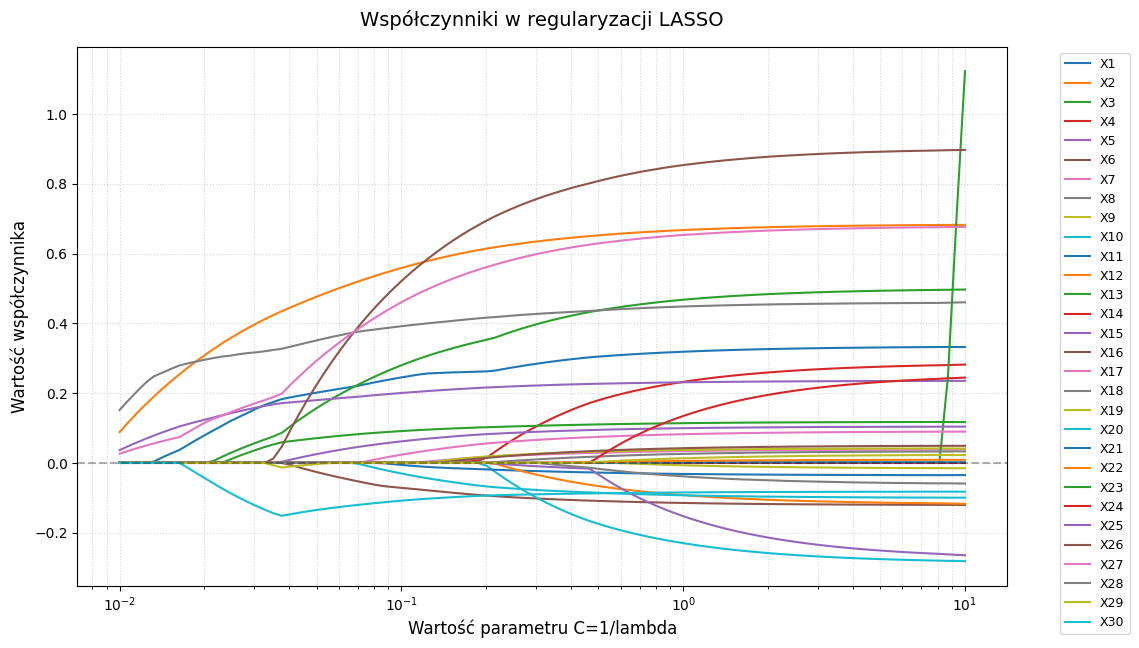

In [31]:
coefs_array = np.array(coefs)

# 2. Tworzenie wykresu
plt.figure(figsize=(12, 7))

# Rysujemy linie dla wszystkich cech na raz. 
# Matplotlib automatycznie przypisze każdej zmiennej inny kolor.
plt.plot(C_val, coefs_array)

# SKALA LOGARYTMICZNA - bez tego wykres będzie "ściśnięty" z jednej strony
plt.xscale('log')

# Dodanie linii poziomej na poziomie 0, aby widzieć, które cechy się zerują
plt.axhline(0, color='black', linestyle='--', alpha=0.3)

plt.legend(df_train.columns, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)

# Opisy osi i tytuł
plt.xlabel('Wartość parametru C=1/lambda', fontsize=12)
plt.ylabel('Wartość współczynnika', fontsize=12)
plt.title('Współczynniki w regularyzacji LASSO', fontsize=14, pad=15)
plt.grid(True, which="both", linestyle=":", alpha=0.5)

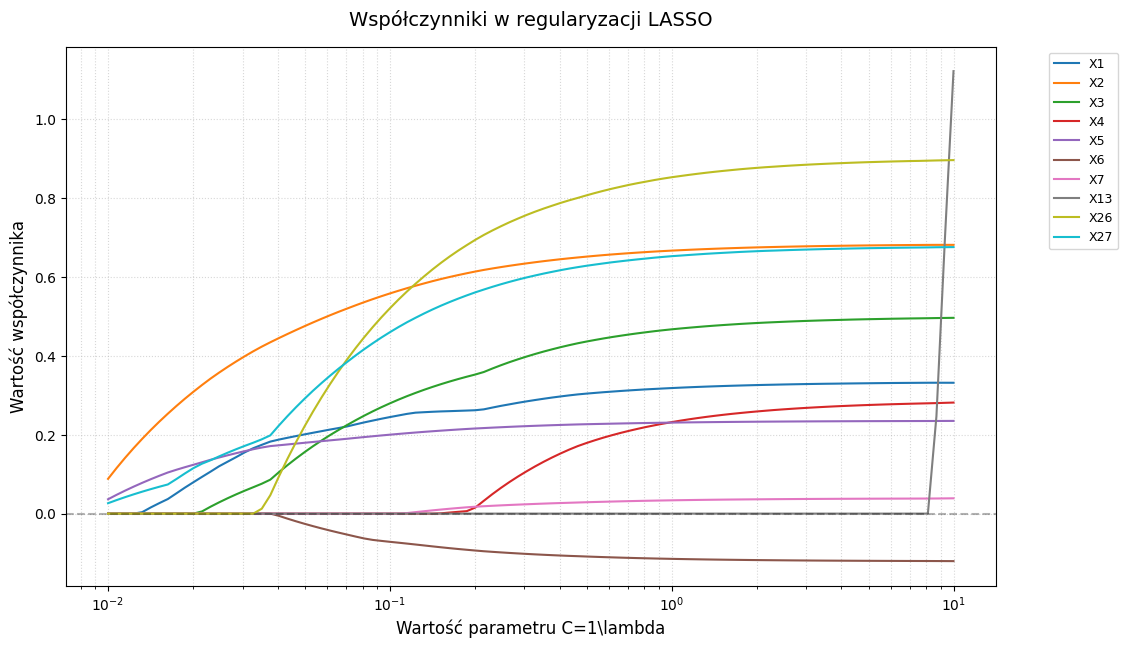

In [32]:
C_val = np.logspace(-2,1,100)
coefs_wybrane = []
wybrane = ['X1', 'X2', 'X3',  'X4', 'X5', 'X6', 'X7', 'X13', 'X26', 'X27']

wybrane_index = [list(df_train.columns).index(f) for f in wybrane]

for c in C_val:
    model = LogisticRegression(penalty='l1',solver='liblinear',C=c,random_state=111)
    model.fit(df_train,df['Y']) 
    coefs_wybrane.append(model.coef_[0][wybrane_index])

coefs_array = np.array(coefs_wybrane)


plt.figure(figsize=(12, 7))


plt.plot(C_val, coefs_array)


plt.xscale('log')


plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.legend(wybrane, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)

plt.xlabel('Wartość parametru C=1\lambda', fontsize=12)
plt.ylabel('Wartość współczynnika', fontsize=12)
plt.title('Współczynniki w regularyzacji LASSO', fontsize=14, pad=15)
plt.grid(True, which="both", linestyle=":", alpha=0.5)

In [33]:
model10 = LogisticRegression(penalty='l1',solver='liblinear',C=0.04,random_state=111)
model10.fit(df_train,df['Y'])
wagi_cech10 = pd.Series(model10.coef_[0], index=df_train.columns)
wagi_10 = abs(wagi_cech10).sort_values(ascending=False)
wagi_10 = wagi_10[wagi_10!=0]
wagi_10

X2     0.443945
X8     0.332055
X27    0.220246
X1     0.187236
X5     0.173093
X30    0.147664
X3     0.102542
X26    0.087881
X23    0.061760
X29    0.010812
X15    0.008336
X6     0.004654
dtype: float64

## Random forest

In [34]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=111)
rf.fit(df_train,df['Y'])

feature_importance = pd.Series(rf.feature_importances_, index=df_train.columns).sort_values(ascending=False)
feature_importance.head(10)

X2     0.071027
X8     0.061413
X4     0.061404
X1     0.060269
X10    0.051023
X3     0.046030
X27    0.042330
X7     0.041087
X12    0.041084
X15    0.038965
dtype: float64

# Metody obudowane

## Forward Selection

In [35]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(solver='liblinear', random_state=111)

forward = SequentialFeatureSelector(
    model, 
    n_features_to_select=10, 
    direction='forward', 
    cv=5, 
    n_jobs=-1
)

forward.fit(df_train,df['Y'])

,estimator,LogisticRegre...r='liblinear')
,n_features_to_select,10
,tol,None
,direction,'forward'
,scoring,None
,cv,5
,n_jobs,-1
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [36]:
wybrane_forward = df_train.columns[forward.get_support()]
wybrane_forward

Index(['X1', 'X2', 'X3', 'X5', 'X9', 'X11', 'X26', 'X27', 'X28', 'X29'], dtype='str')

In [37]:
backward = SequentialFeatureSelector(
    model, 
    n_features_to_select=10, 
    direction='backward', 
    cv=5, 
    n_jobs=-1
)

backward.fit(df_train,df['Y'])

,estimator,LogisticRegre...r='liblinear')
,n_features_to_select,10
,tol,None
,direction,'backward'
,scoring,None
,cv,5
,n_jobs,-1
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [38]:
wybrane_backward= df_train.columns[backward.get_support()]
wybrane_backward

Index(['X2', 'X3', 'X5', 'X6', 'X7', 'X8', 'X17', 'X23', 'X26', 'X27'], dtype='str')

## RFE z random forest

In [39]:
from sklearn.feature_selection import RFECV

rf_model = RandomForestClassifier(random_state=111,n_jobs=-1)


rfecv_selection = RFECV(
    estimator=rf_model, 
    step=1, 
    cv=5, 
    scoring='accuracy', 
    min_features_to_select=10, 
    n_jobs=-1
)

rfecv_selection.fit(df_train,df['Y'])

,estimator,RandomForestC...dom_state=111)
,step,1
,min_features_to_select,10
,cv,5
,scoring,'accuracy'
,verbose,0
,n_jobs,-1
,importance_getter,'auto'
,n_estimators,100
,criterion,'gini'
,max_depth,None


In [40]:
rfecv_cechy = df_train.columns[rfecv_selection.support_]
rfecv_cechy

Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11',
       'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X24',
       'X25', 'X26', 'X27'],
      dtype='str')

In [41]:
from sklearn.feature_selection import RFE

rfe_selection = RFE(
    estimator=rf_model, 
    step=1,  
    n_features_to_select=10
)

rfe_selection.fit(df_train,df['Y'])

,estimator,RandomForestC...dom_state=111)
,n_features_to_select,10
,step,1
,verbose,0
,importance_getter,'auto'
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


In [42]:
rfe_cechy = df_train.columns[rfe_selection.support_]
rfe_cechy

Index(['X1', 'X2', 'X3', 'X4', 'X6', 'X7', 'X8', 'X9', 'X10', 'X12'], dtype='str')

In [47]:
from sklearn.ensemble import RandomForestClassifier
# Import z nowej, działającej biblioteki
from sklearn_genetic import GAFeatureSelectionCV

# 1. Model oceniający
estimator = RandomForestClassifier(random_state=42, n_jobs=-1)

# 2. Selektor genetyczny
selector_ga = GAFeatureSelectionCV(
    estimator,
    cv=5,
    scoring="accuracy",
    max_features=10,                # Miękki limit: szukamy max 10 cech
    crossover_probability=0.5,
    mutation_probability=0.2,
    n_jobs=-1,
    verbose=True
)

# 3. Uruchomienie ewolucji
selector_ga.fit(df_train, df['Y'])

# 4. Wyciągnięcie cech
wybrane_ga = df_train.columns[selector_ga.support_]
print("\nCechy wybrane przez Algorytm Genetyczny:")
print(wybrane_ga.tolist())

ImportError: Traceback (most recent call last):
  File "c:\Users\wolfd\anaconda3\Lib\site-packages\tensorflow\python\pywrap_tensorflow.py", line 73, in <module>
    from tensorflow.python._pywrap_tensorflow_internal import *
ImportError: DLL load failed while importing _pywrap_tensorflow_internal: Procedura inicjowania biblioteki dołączanej dynamicznie (DLL) nie powiodła się.


Failed to load the native TensorFlow runtime.
See https://www.tensorflow.org/install/errors for some common causes and solutions.
If you need help, create an issue at https://github.com/tensorflow/tensorflow/issues and include the entire stack trace above this error message.

In [46]:
!pip install sklearn-genetic-opt